# QINCo AQ: Relative Error and FAISS ADC Timing

This notebook uses the completed QINCo outputs under `/mnthdd/cpanourg/2-hdvc/results/qinco`:

- FAISS timing CSVs: `timing_csvs/*_QINCo2_adc_vs_exact_eval.csv`
- Dense ADC accuracy summary: `qinco_dense_adc_accuracy_summary.csv`
- Dense distance matrices: `dense_adc_distances/**/{adc_distances_sq,exact_distances_sq,relative_errors}.npy`

Timing and accuracy are intentionally separated: timing comes from FAISS C++ ADC search, while relative error comes from dense NumPy distance exports.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

PROJECT_ROOT = Path('/home/cpanourg/projects/2-hdvc')
FIGURE_DIR = PROJECT_ROOT / 'scripts' / 'figure_generators'
if str(FIGURE_DIR) not in sys.path:
    sys.path.insert(0, str(FIGURE_DIR))

from relerr_quick_plot_style import (
    COLOR_PALETTE,
    MARKER_PALETTE,
    apply_relerr_cpp_rcparams,
    plot_curve_relerr_style,
    style_axes_relerr_vs_metric,
)

RESULT_ROOT = Path('/mnthdd/cpanourg/2-hdvc/results/qinco')
TIMING_DIR = RESULT_ROOT / 'timing_csvs'
ACCURACY_CSV = RESULT_ROOT / 'qinco_dense_adc_accuracy_summary.csv'
OUT_DIR = RESULT_ROOT / 'figures' / 'qinco_res_relerr'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['bigann', 'deep', 'gist', 'msmarco', 'openai']
SAVE_FORMATS = ('png', 'pdf')

apply_relerr_cpp_rcparams()
print('Timing dir:', TIMING_DIR)
print('Accuracy CSV:', ACCURACY_CSV)
print('Output dir:', OUT_DIR)


Timing dir: /mnthdd/cpanourg/2-hdvc/results/qinco/timing_csvs
Accuracy CSV: /mnthdd/cpanourg/2-hdvc/results/qinco/qinco_dense_adc_accuracy_summary.csv
Output dir: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr


In [2]:
def _numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def load_qinco_timing(timing_dir: Path = TIMING_DIR) -> pd.DataFrame:
    paths = sorted(timing_dir.glob('*_QINCo2_adc_vs_exact_eval.csv'))
    if not paths:
        raise FileNotFoundError(f'No timing CSVs found in {timing_dir}')
    frames = []
    for path in paths:
        df = pd.read_csv(path)
        if 'dataset' not in df.columns:
            df['dataset'] = path.name.split('_')[0]
        frames.append(df)
    timing = pd.concat(frames, ignore_index=True)
    timing = _numeric(
        timing,
        ['n_subquantizers', 'nbits', 'bits_per_vector', 'adc_time_s', 'per_pair_adc_time_ns', 'nq', 'nb_sample'],
    )
    timing['M'] = timing['n_subquantizers'].astype('Int64')
    timing['K'] = (2 ** timing['nbits'].astype(int)).astype(int)
    timing['adc_time_per_pair_ns'] = timing['per_pair_adc_time_ns']
    return timing


def load_qinco_accuracy(accuracy_csv: Path = ACCURACY_CSV) -> pd.DataFrame:
    if not accuracy_csv.is_file():
        raise FileNotFoundError(accuracy_csv)
    accuracy = pd.read_csv(accuracy_csv)
    accuracy = _numeric(
        accuracy,
        [
            'n_subquantizers', 'n_centroids', 'nbits', 'bits_per_vector',
            'rel_error_mean', 'rel_error_std', 'rel_error_min', 'rel_error_max',
            'n_queries', 'n_db',
        ],
    )
    accuracy['M'] = accuracy['n_subquantizers'].astype('Int64')
    accuracy['K'] = accuracy['n_centroids'].astype('Int64')
    return accuracy


def build_plot_df() -> pd.DataFrame:
    timing = load_qinco_timing()
    accuracy = load_qinco_accuracy()
    key_cols = ['dataset', 'M', 'K', 'nbits', 'bits_per_vector']

    timing_agg = (
        timing.groupby(key_cols, as_index=False)
        .agg(
            adc_time_s=('adc_time_s', 'mean'),
            adc_time_per_pair_ns=('adc_time_per_pair_ns', 'mean'),
            nq=('nq', 'mean'),
            nb_sample=('nb_sample', 'mean'),
            timing_rows=('adc_time_s', 'size'),
        )
    )
    accuracy_agg = (
        accuracy.groupby(key_cols, as_index=False)
        .agg(
            rel_error_mean=('rel_error_mean', 'mean'),
            rel_error_std=('rel_error_std', 'mean'),
            rel_error_min=('rel_error_min', 'min'),
            rel_error_max=('rel_error_max', 'max'),
            n_queries=('n_queries', 'mean'),
            n_db=('n_db', 'mean'),
            accuracy_rows=('rel_error_mean', 'size'),
        )
    )
    df = timing_agg.merge(accuracy_agg, on=key_cols, how='outer', validate='one_to_one')
    df['method'] = 'QINCo2'
    df = df.sort_values(['dataset', 'bits_per_vector', 'M', 'K']).reset_index(drop=True)
    return df

plot_df = build_plot_df()
print('Rows:', len(plot_df))
print(plot_df.groupby('dataset').size())
plot_df.head()


Rows: 151
dataset
bigann     31
deep       35
gist       30
msmarco    30
openai     25
dtype: int64


,dataset,M,K,nbits,bits_per_vector,adc_time_s,adc_time_per_pair_ns,nq,nb_sample,timing_rows,rel_error_mean,rel_error_std,rel_error_min,rel_error_max,n_queries,n_db,accuracy_rows,method
0,bigann,1,16,4,4,0.101092,10.109179,1000.0,10000.0,1,0.357553,0.124413,7.238890e-08,19.336430,1000.0,10000.0,1,QINCo2
1,bigann,1,64,6,6,0.103383,10.338258,1000.0,10000.0,1,0.308968,0.119529,2.283163e-07,12.868905,1000.0,10000.0,1,QINCo2
2,bigann,1,256,8,8,0.101661,10.166091,1000.0,10000.0,1,0.266311,0.115638,3.498839e-07,7.596001,1000.0,10000.0,1,QINCo2
3,bigann,2,16,4,8,0.124985,12.498486,1000.0,10000.0,1,0.328954,0.121042,4.668081e-07,20.790081,1000.0,10000.0,1,QINCo2
4,bigann,1,1024,10,10,0.171682,17.168177,1000.0,10000.0,1,0.226253,0.110220,0.000000e+00,6.655904,1000.0,10000.0,1,QINCo2


In [3]:
def style_axes(ax, x_label: str, y_label: str, *, grid_axis: str = 'y', x_log: bool = False, y_log: bool = False):
    ax.set_xlabel(x_label, fontsize=40)
    ax.set_ylabel(y_label, fontsize=40)
    ax.tick_params(labelsize=40)
    if x_log:
        ax.set_xscale('log')
    if y_log:
        ax.set_yscale('log')
    ax.grid(False)
    ax.grid(alpha=0.8, axis=grid_axis, linestyle='--')
    for spine in ax.spines.values():
        spine.set_visible(False)
    if not x_log:
        fmt_x = ScalarFormatter(useMathText=False)
        fmt_x.set_scientific(False)
        ax.xaxis.set_major_formatter(fmt_x)
    if not y_log:
        fmt_y = ScalarFormatter(useMathText=False)
        fmt_y.set_scientific(False)
        ax.yaxis.set_major_formatter(fmt_y)


def save_figure(fig, stem: str):
    saved = []
    for fmt in SAVE_FORMATS:
        path = OUT_DIR / f'{stem}.{fmt}'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        saved.append(path)
    print('Saved:', ', '.join(str(p) for p in saved))


def plot_lines_by_group(
    df: pd.DataFrame,
    *,
    dataset: str,
    x_col: str,
    y_col: str,
    group_col: str,
    x_label: str,
    y_label: str,
    stem: str,
    title: str | None = None,
    x_log: bool = False,
    y_log: bool = False,
):
    sub = df[df['dataset'] == dataset].dropna(subset=[x_col, y_col, group_col]).copy()
    if sub.empty:
        return None
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (group_value, group_df) in enumerate(sorted(sub.groupby(group_col), key=lambda kv: float(kv[0]))):
        group_df = group_df.sort_values(x_col)
        label = f'{group_col}={int(group_value)}'
        plot_curve_relerr_style(
            ax,
            group_df,
            x_col=x_col,
            y_col=y_col,
            label=label,
            color=COLOR_PALETTE[i % len(COLOR_PALETTE)],
            marker=MARKER_PALETTE[i % len(MARKER_PALETTE)],
        )
    style_axes(ax, x_label, y_label, x_log=x_log, y_log=y_log)
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=18)
    plt.tight_layout()
    save_figure(fig, f'{dataset}_{stem}')
    return fig, ax


def plot_heatmap(
    df: pd.DataFrame,
    *,
    dataset: str,
    value_col: str,
    value_label: str,
    stem: str,
    cmap: str = 'viridis',
):
    sub = df[df['dataset'] == dataset].dropna(subset=['M', 'K', value_col]).copy()
    if sub.empty:
        return None
    pivot = sub.pivot_table(index='M', columns='K', values=value_col, aggfunc='mean').sort_index().sort_index(axis=1)
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 7))
    mat = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
    im = ax.imshow(mat, aspect='auto', origin='lower', cmap=cmap)
    ax.set_xlabel('K', fontsize=40)
    ax.set_ylabel('M', fontsize=40)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(int(v)) for v in pivot.columns], rotation=45, ha='right', fontsize=24)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([str(int(v)) for v in pivot.index], fontsize=24)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_label, fontsize=28)
    cbar.ax.tick_params(labelsize=22)
    plt.tight_layout()
    save_figure(fig, f'{dataset}_{stem}')
    return fig, ax


## Relative Error Plots

The relative-error values below come from dense ADC exports, not from the FAISS timing benchmark.

Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_bits_per_vector_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_bits_per_vector_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_M_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_M_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_K_by_M.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_vs_K_by_M.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_heatmap_M_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_relerr_heatmap_M_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/deep_relerr_vs_bits_per_vector_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/deep_relerr_vs_bits_per_vect

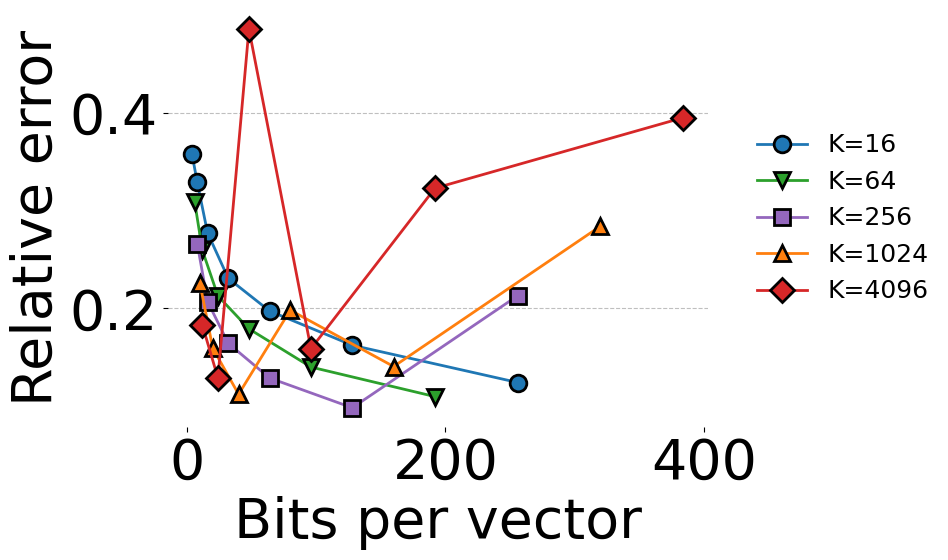

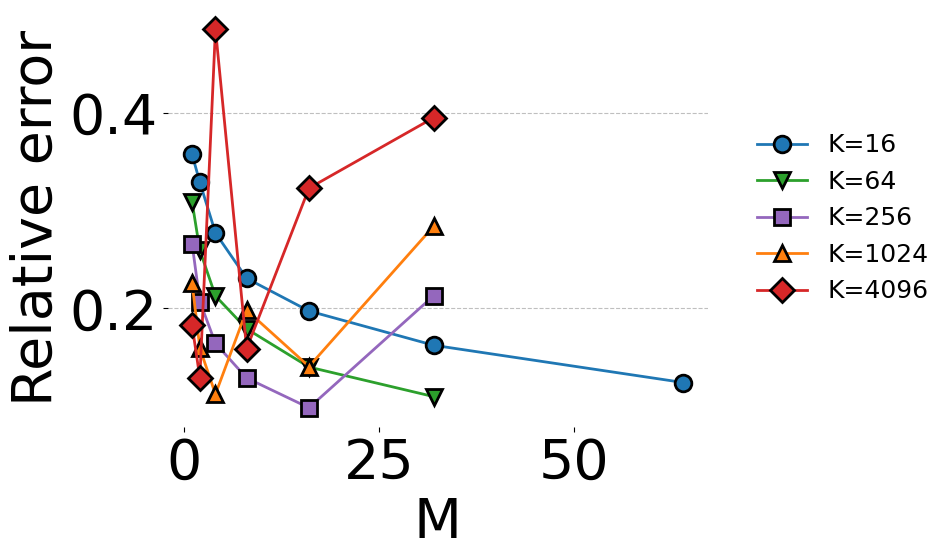

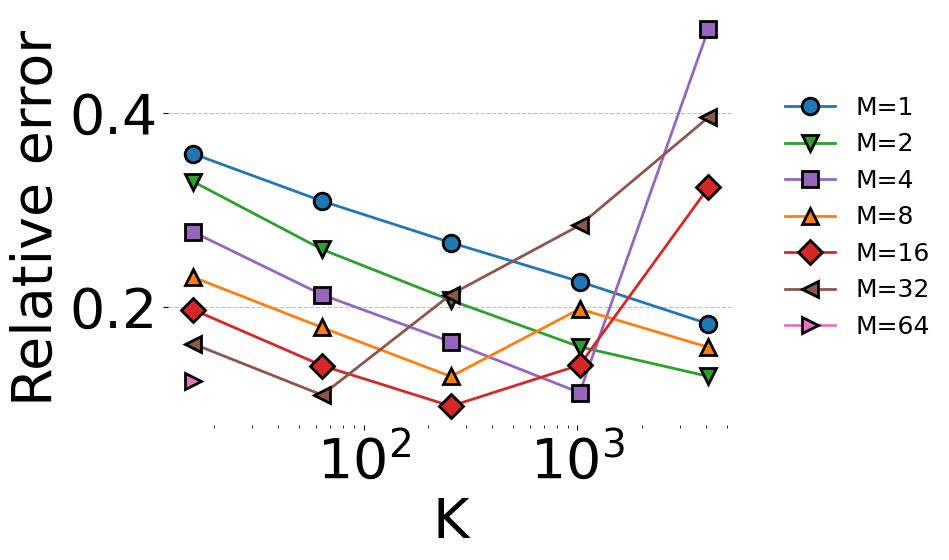

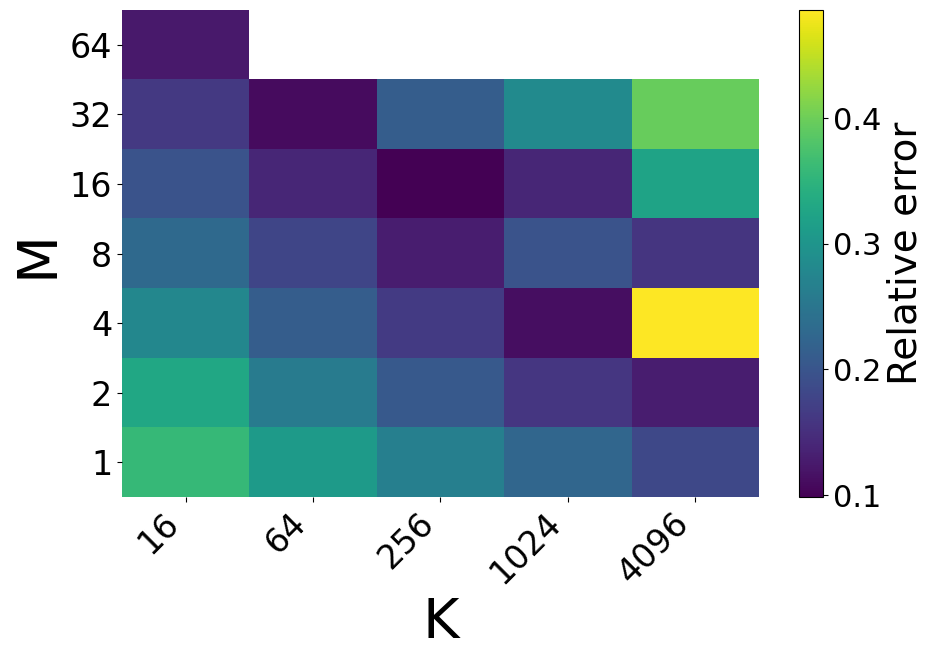

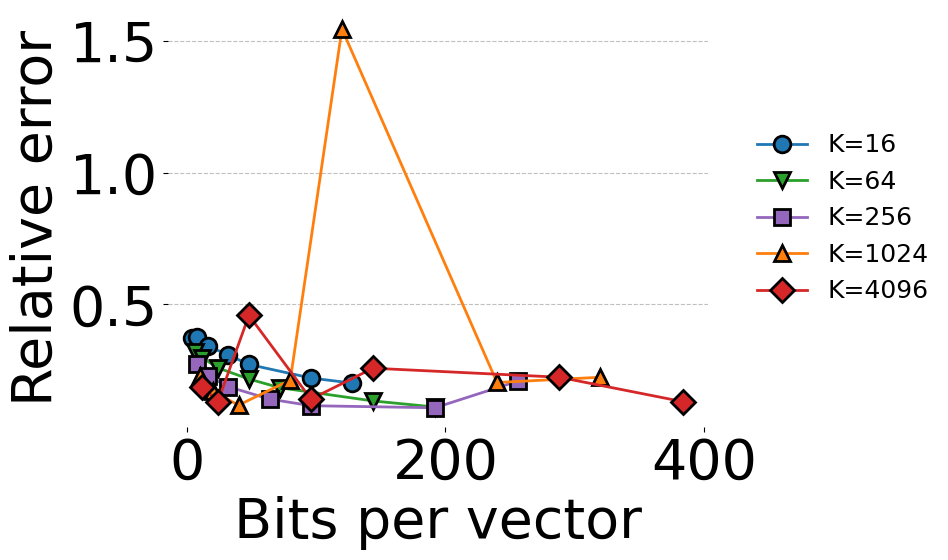

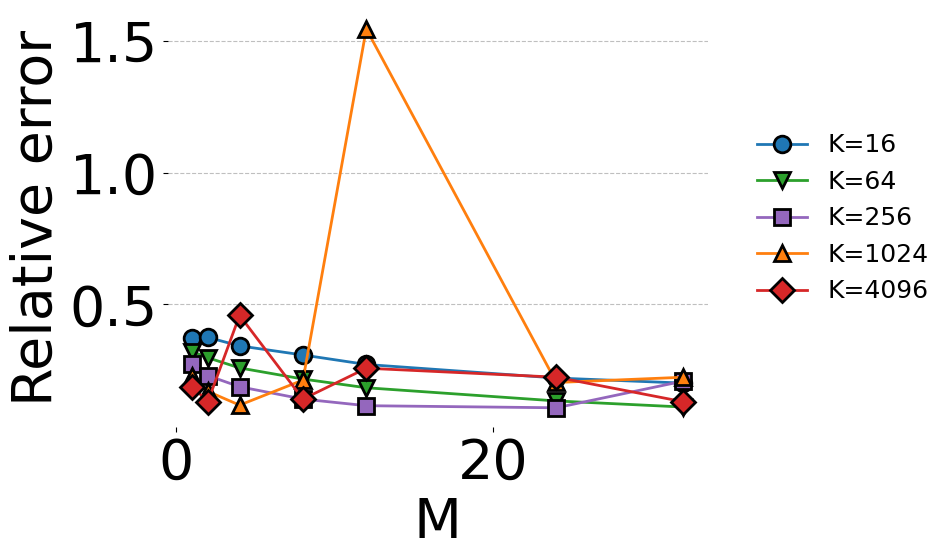

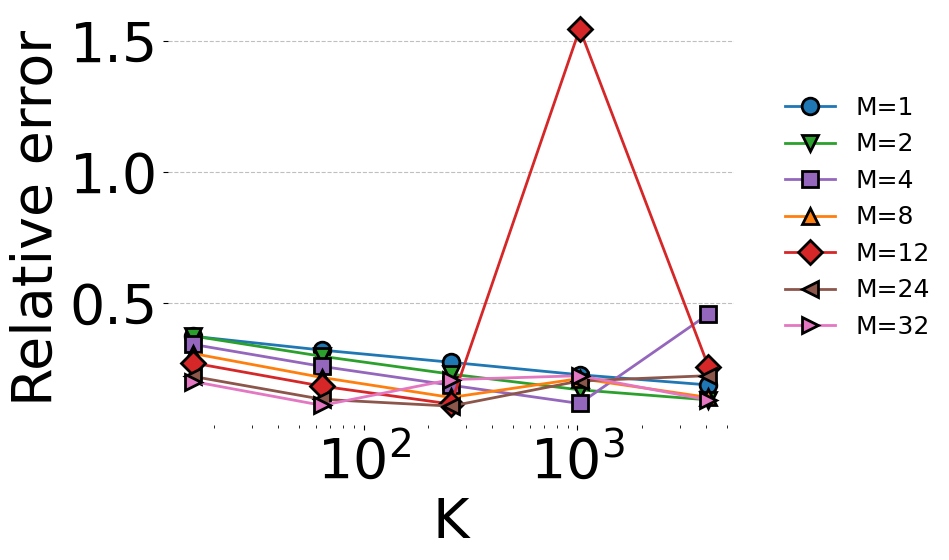

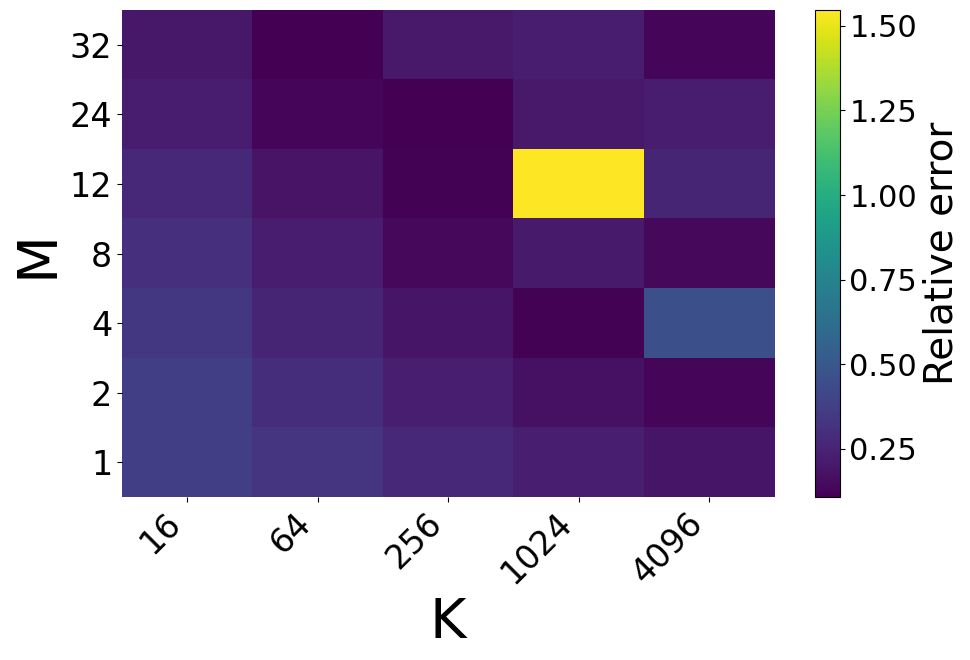

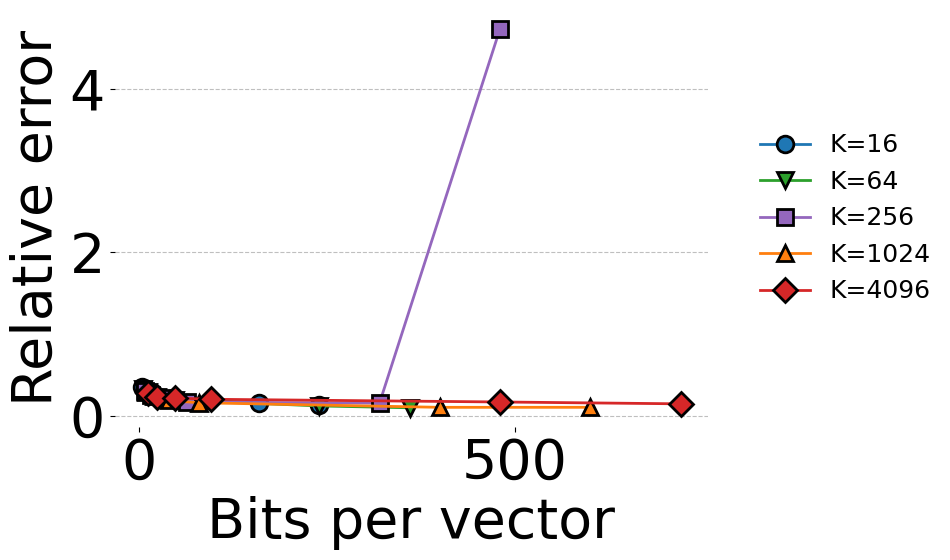

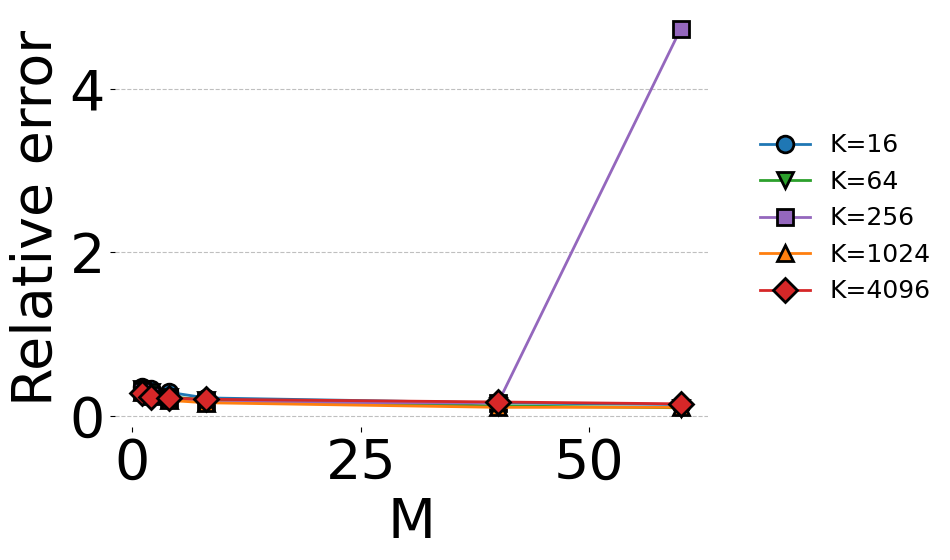

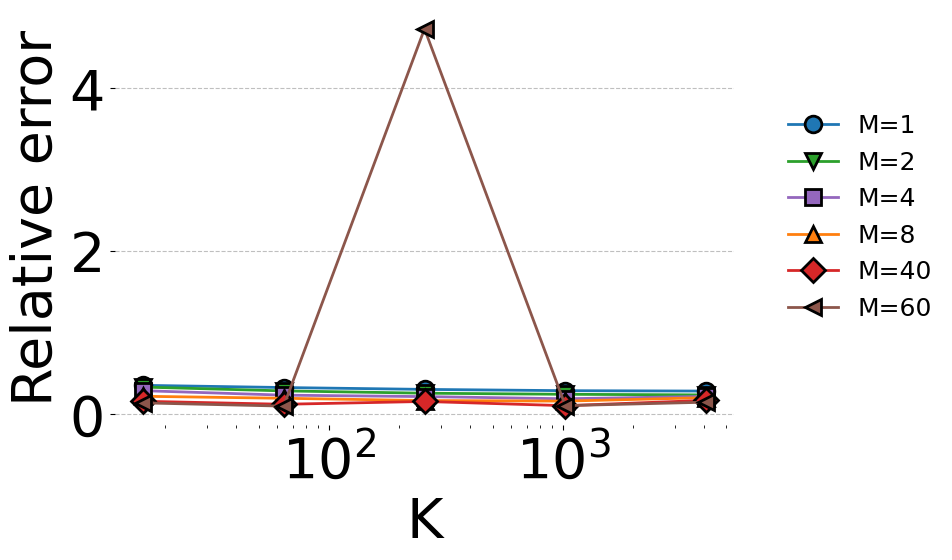

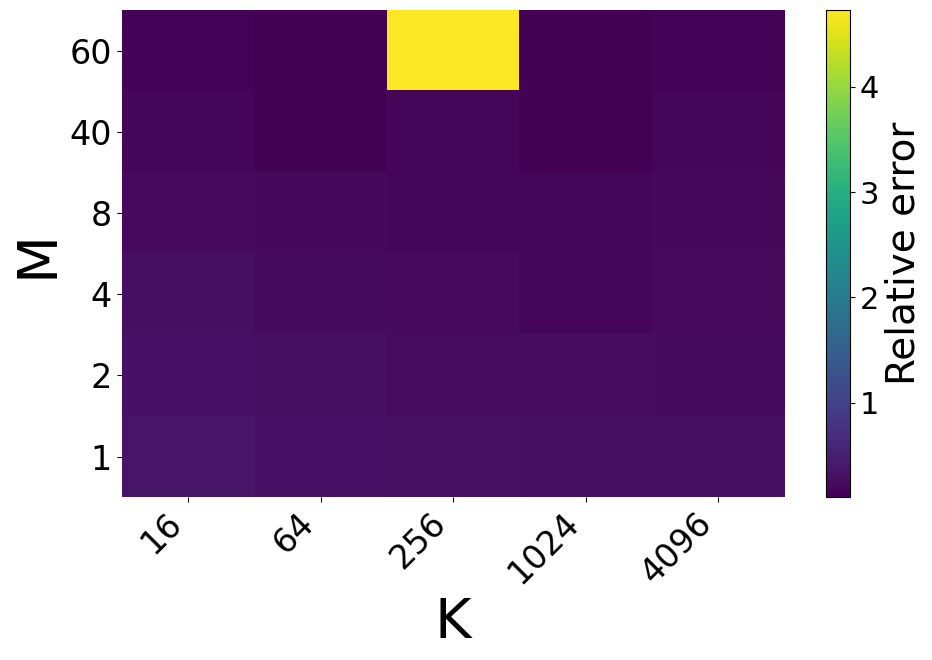

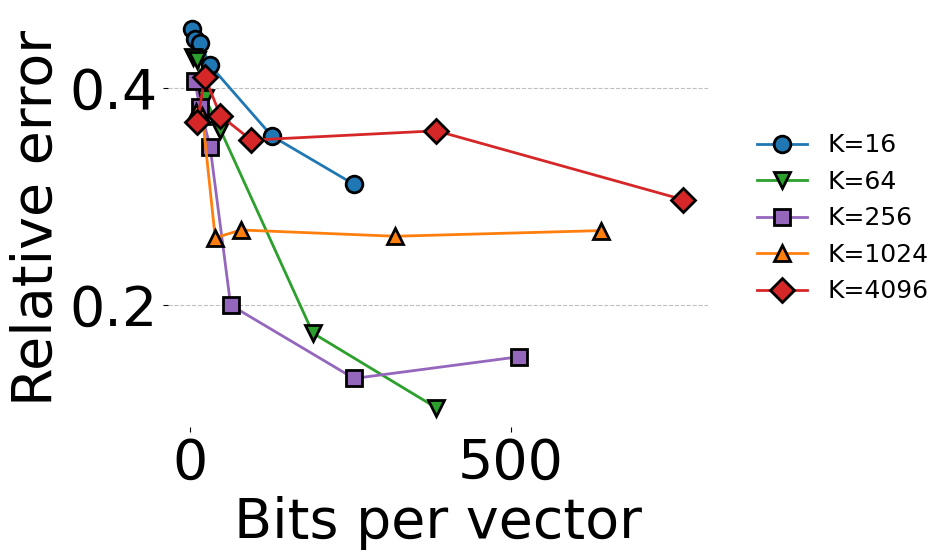

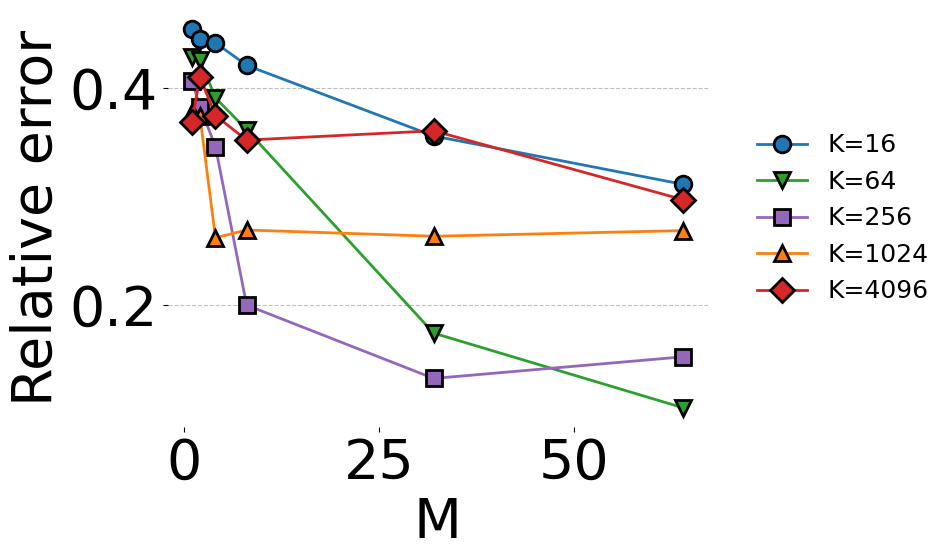

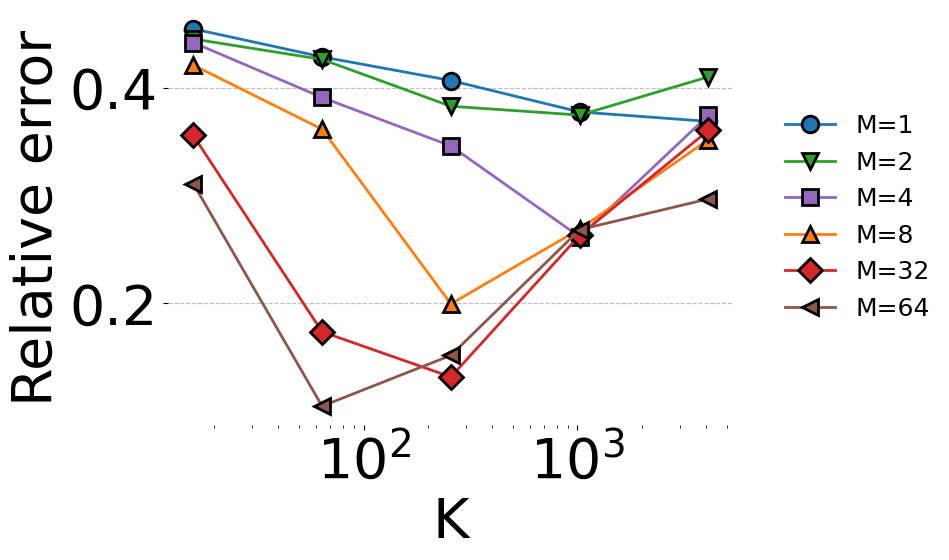

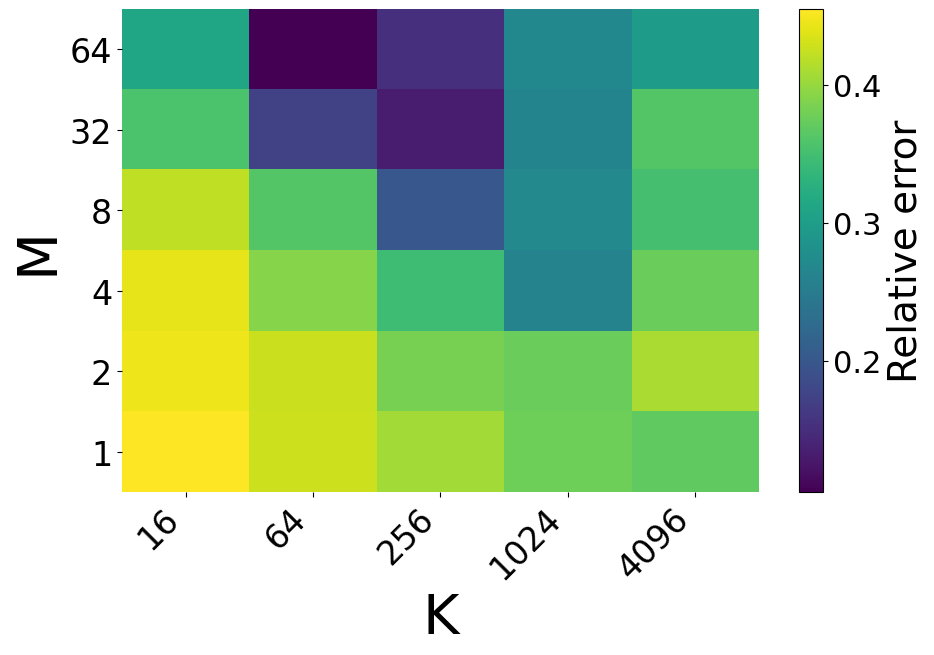

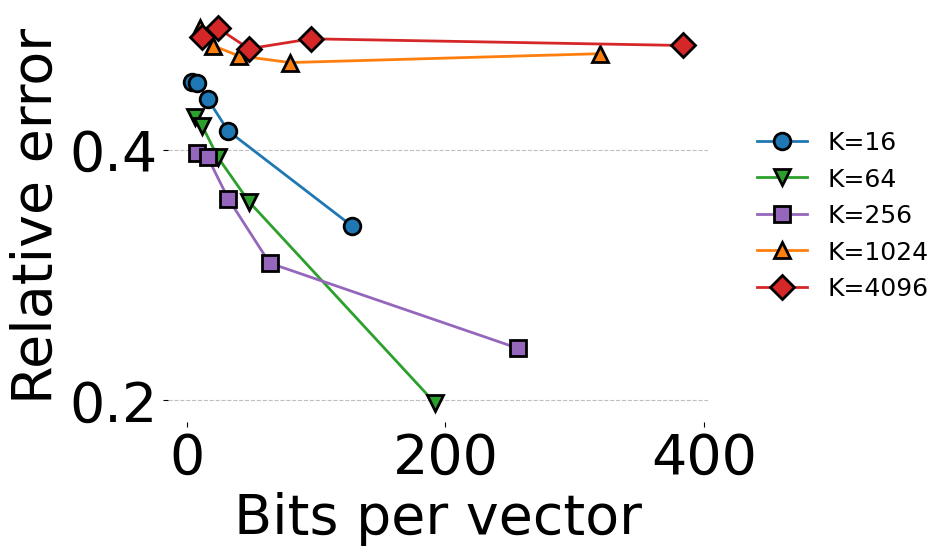

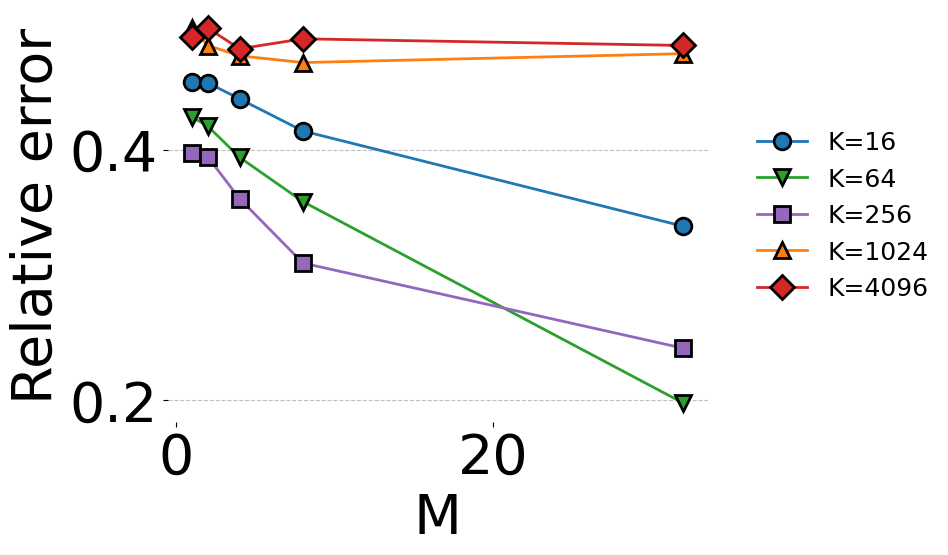

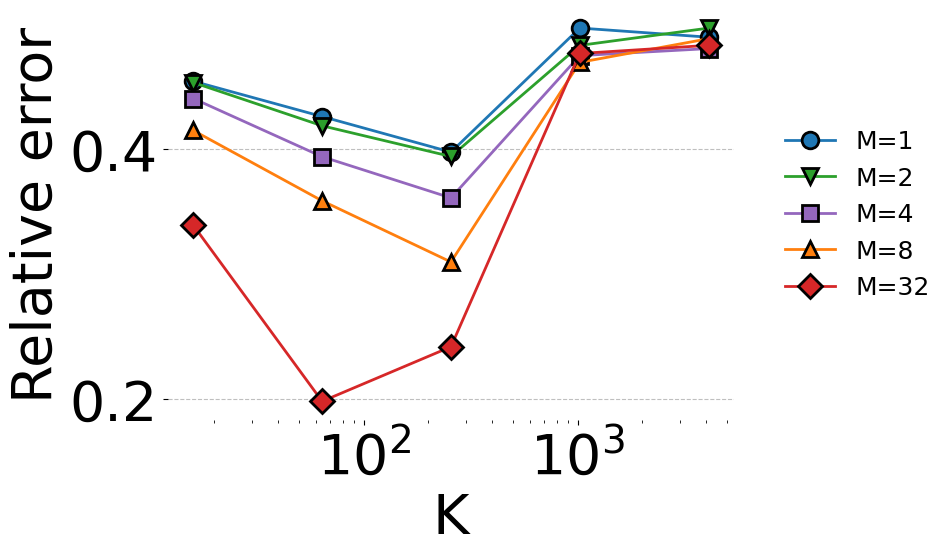

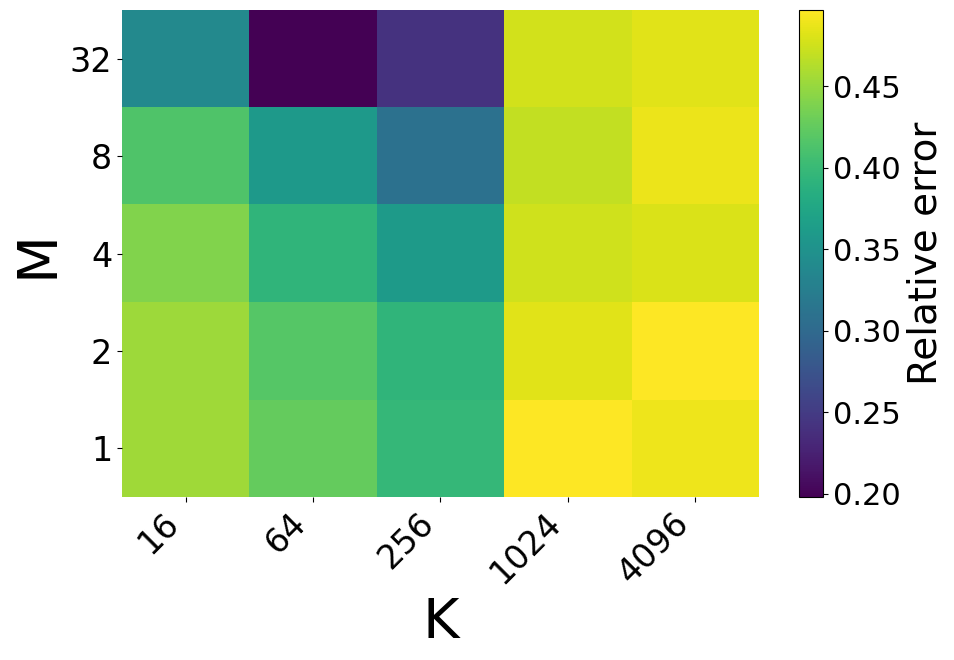

In [4]:
for dataset in DATASETS:
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='bits_per_vector',
        y_col='rel_error_mean',
        group_col='K',
        x_label='Bits per vector',
        y_label='Relative error',
        stem='relerr_vs_bits_per_vector_by_K',
        title=f'{dataset}: Relative error vs bits/vector',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='M',
        y_col='rel_error_mean',
        group_col='K',
        x_label='M',
        y_label='Relative error',
        stem='relerr_vs_M_by_K',
        title=f'{dataset}: Relative error vs M',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='K',
        y_col='rel_error_mean',
        group_col='M',
        x_label='K',
        y_label='Relative error',
        stem='relerr_vs_K_by_M',
        title=f'{dataset}: Relative error vs K',
        x_log=True,
    )
    plot_heatmap(
        plot_df,
        dataset=dataset,
        value_col='rel_error_mean',
        value_label='Relative error',
        stem='relerr_heatmap_M_by_K',
    )


## FAISS ADC Timing Plots

`adc_time_per_pair_ns` is the fair FAISS C++ timing normalized by `n_queries * n_db_sample`.

Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_bits_per_vector_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_bits_per_vector_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_M_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_M_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_K_by_M.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_vs_K_by_M.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_heatmap_M_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_adc_time_ns_heatmap_M_by_K.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/deep_adc_time_ns_vs_bits_per_vector_by_K.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/

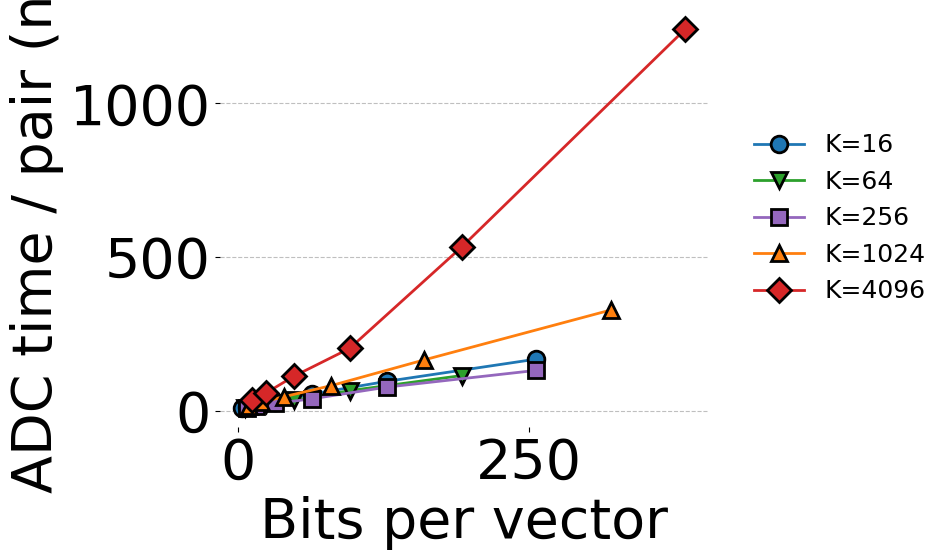

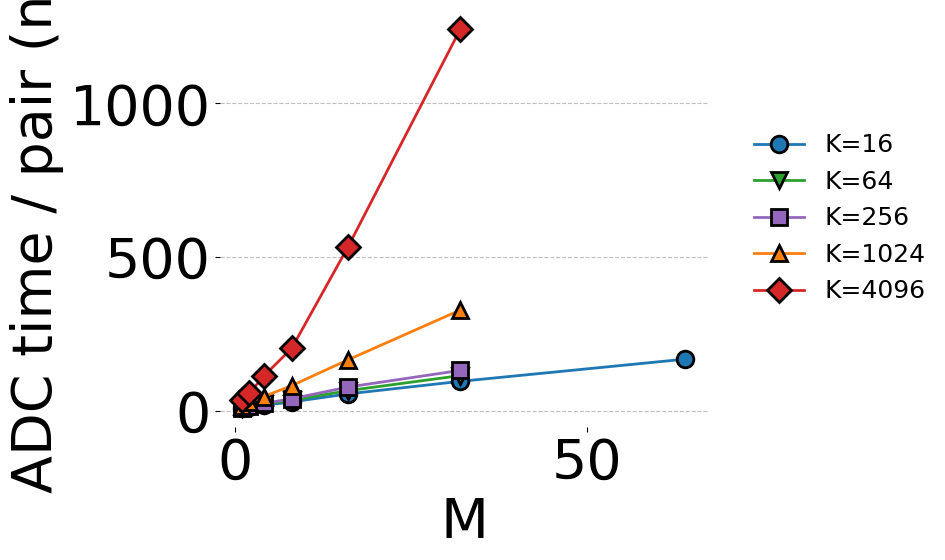

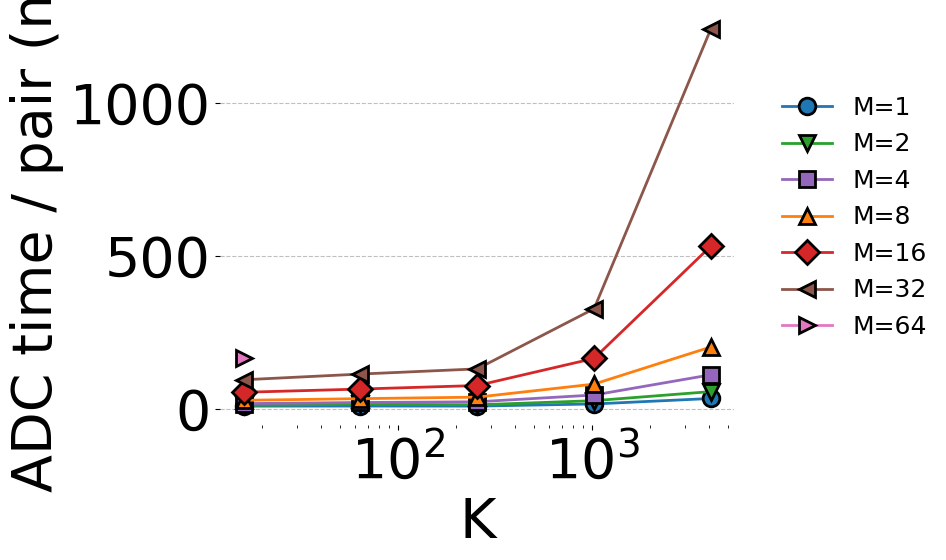

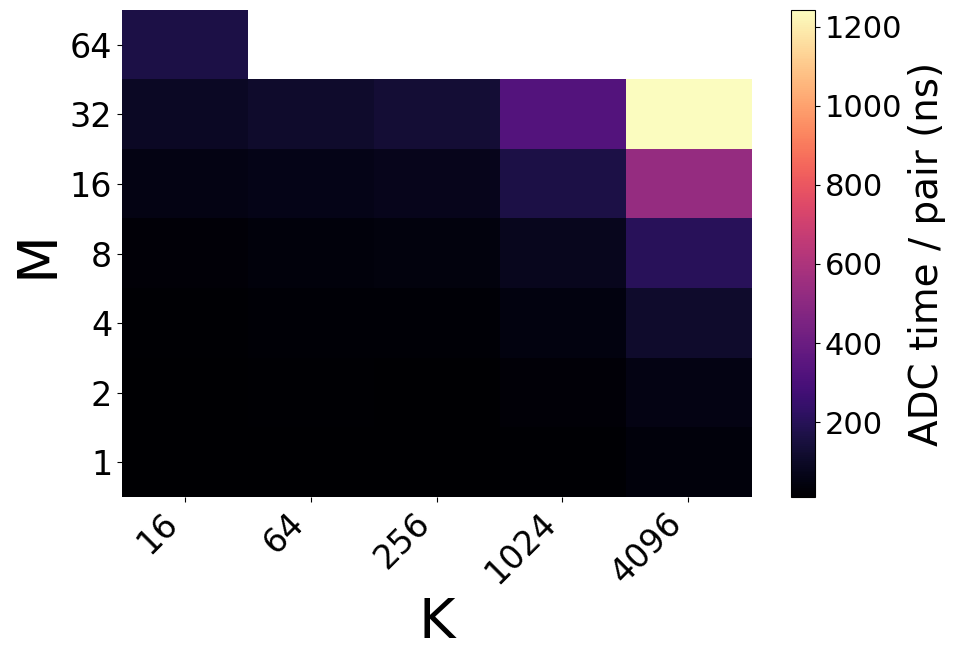

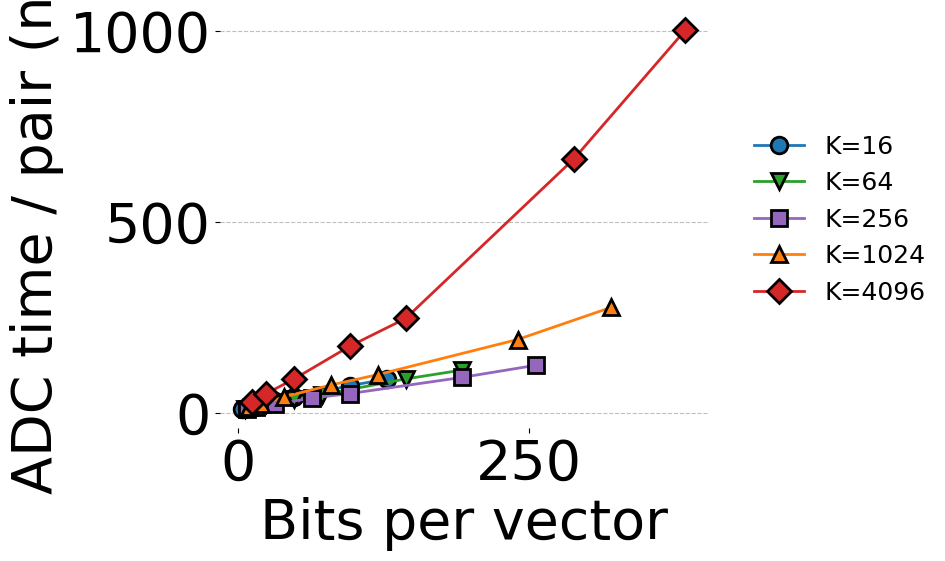

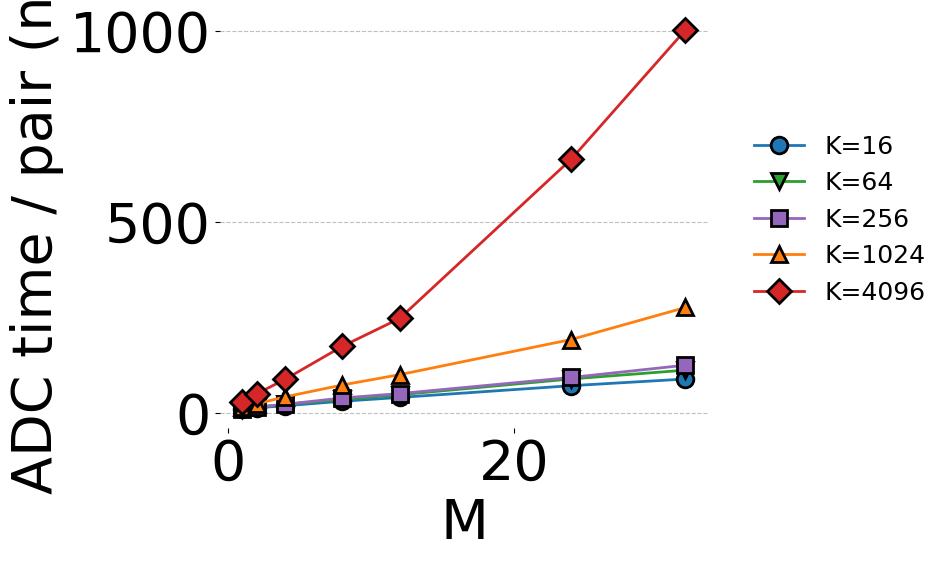

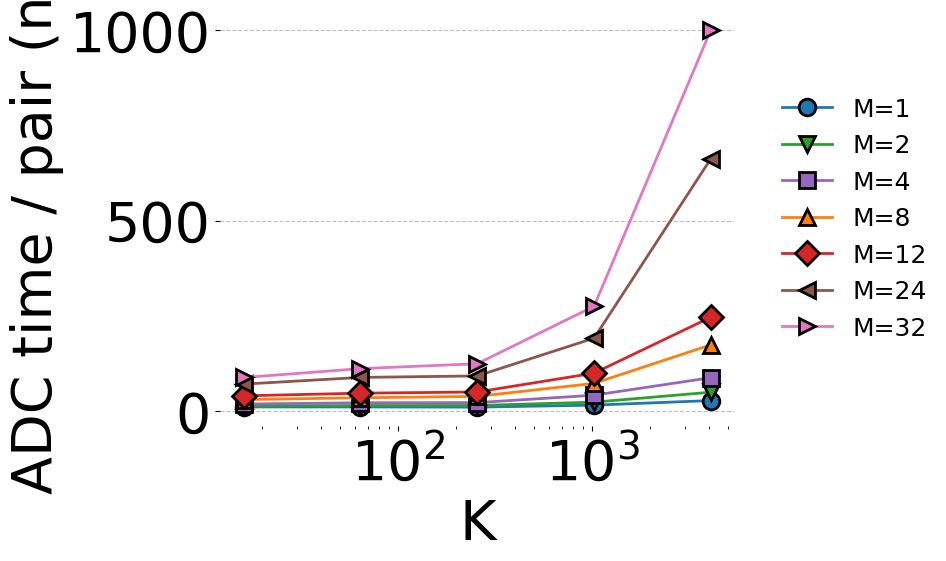

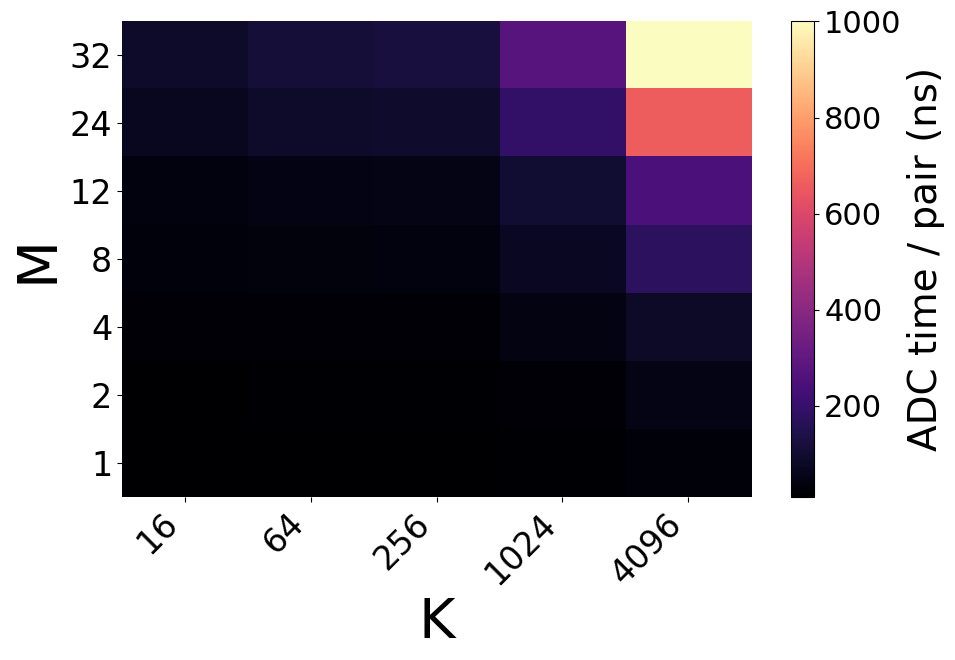

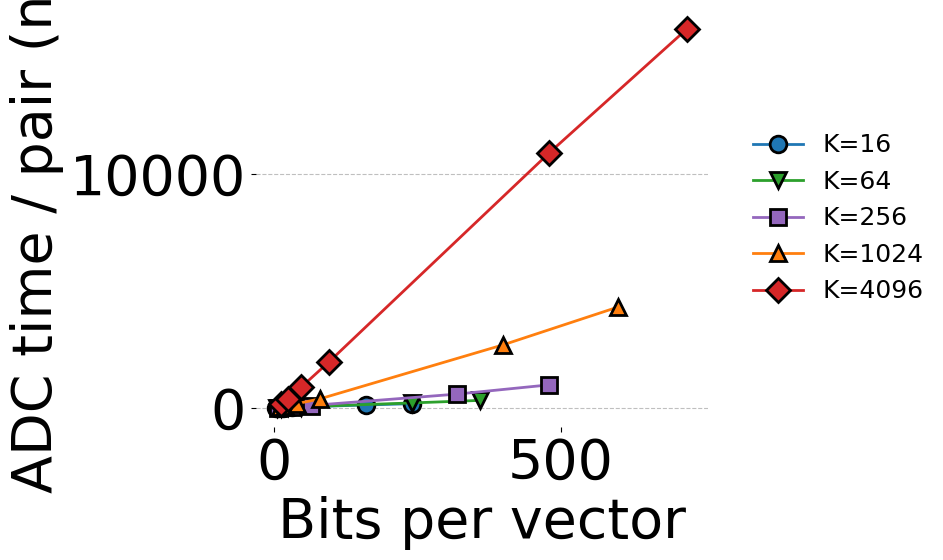

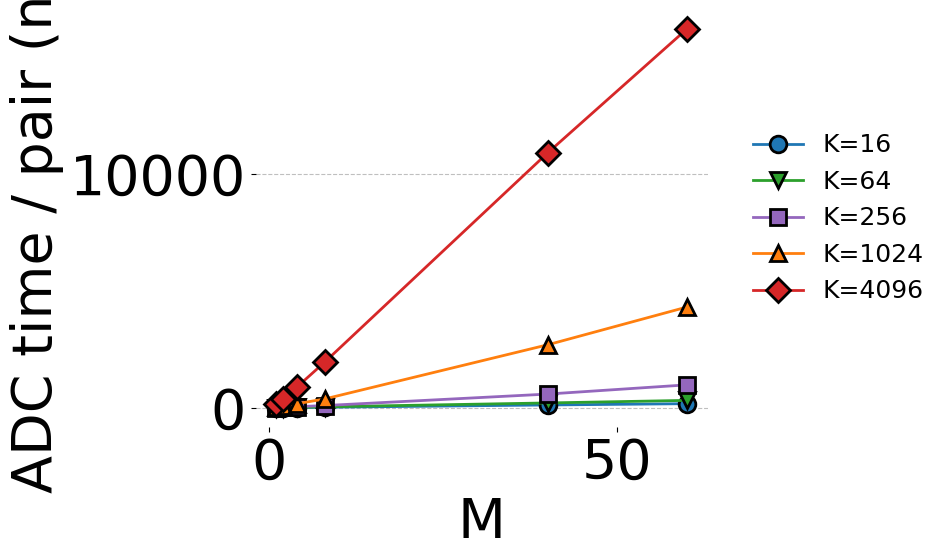

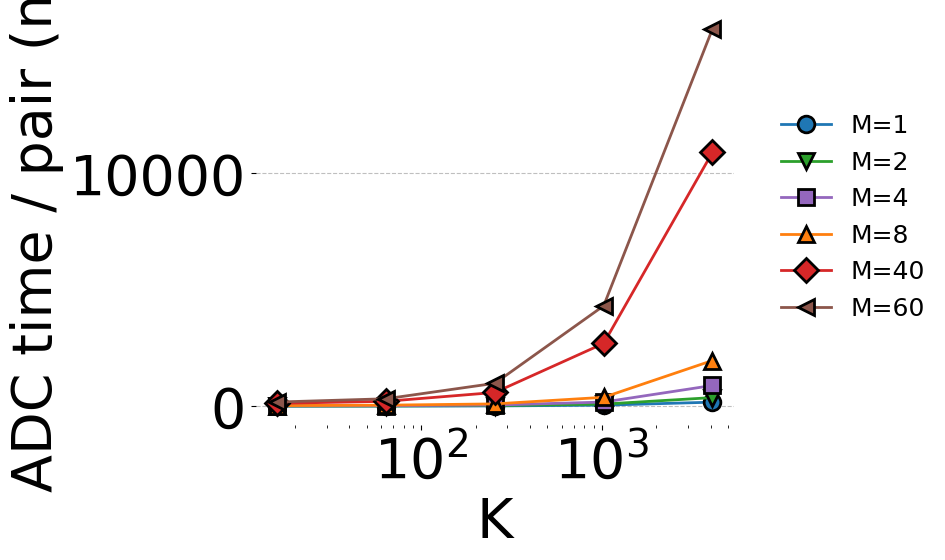

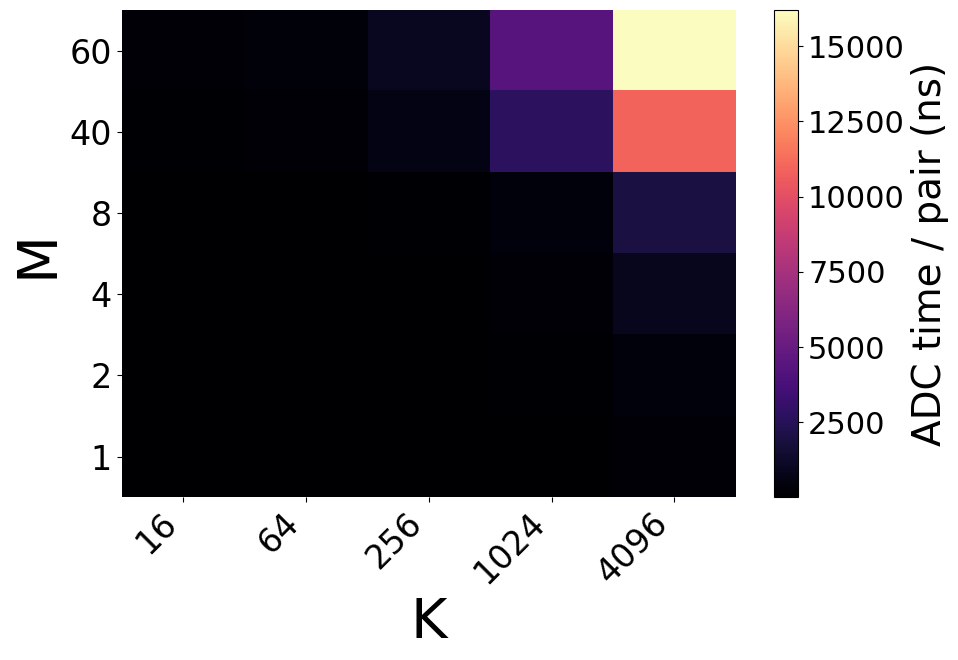

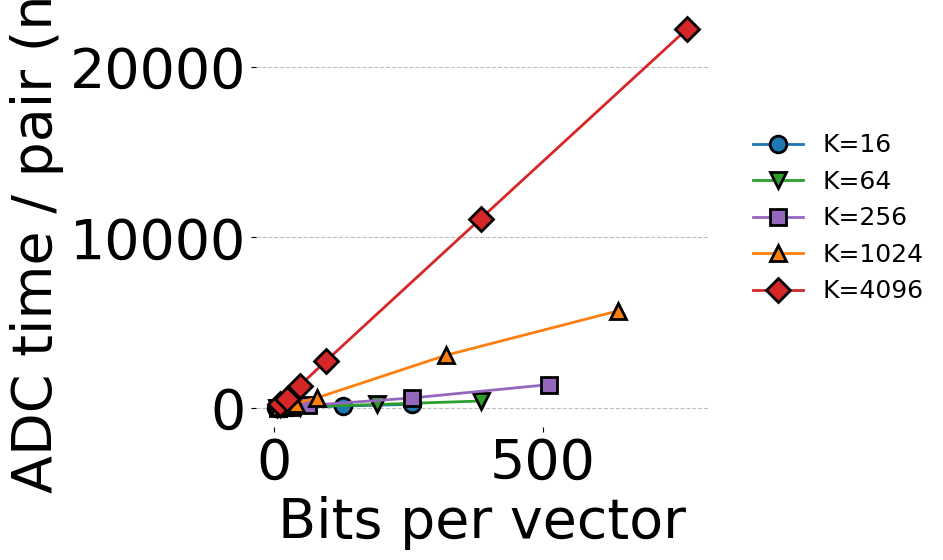

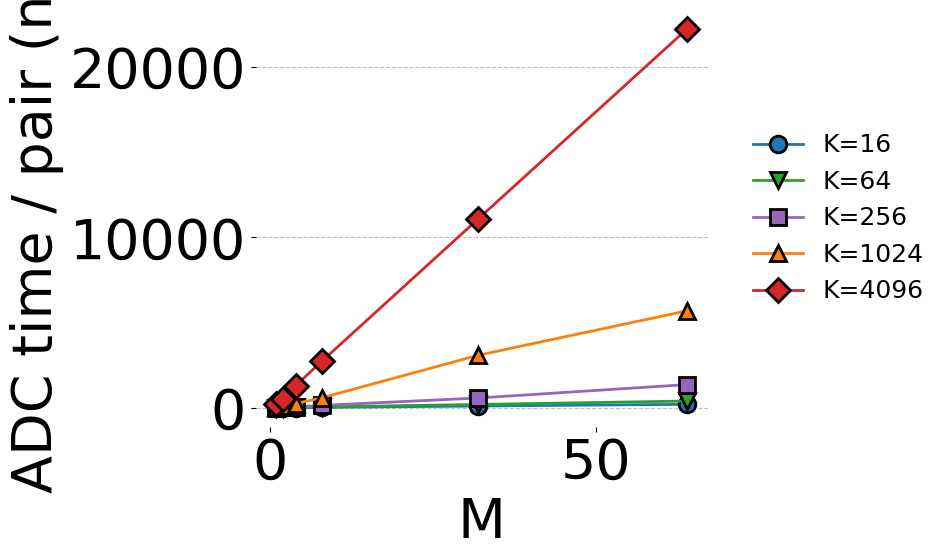

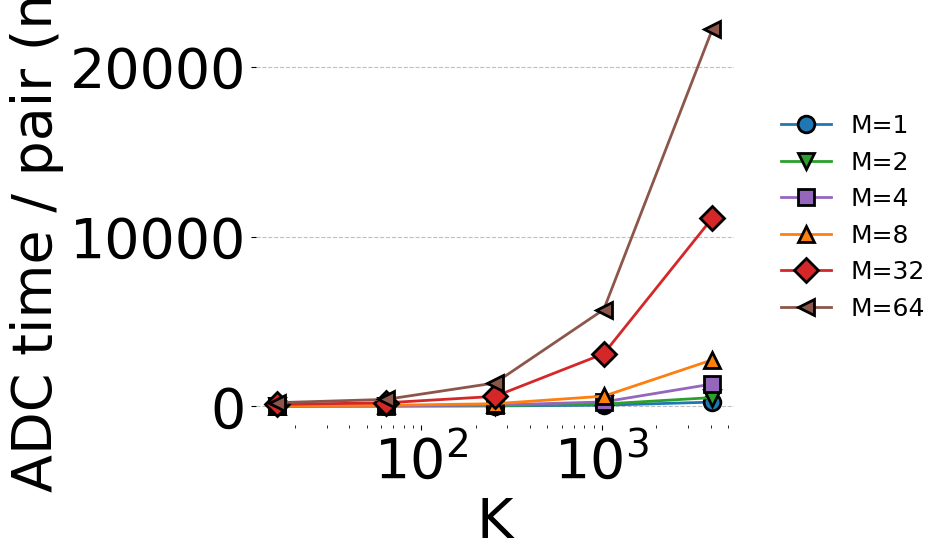

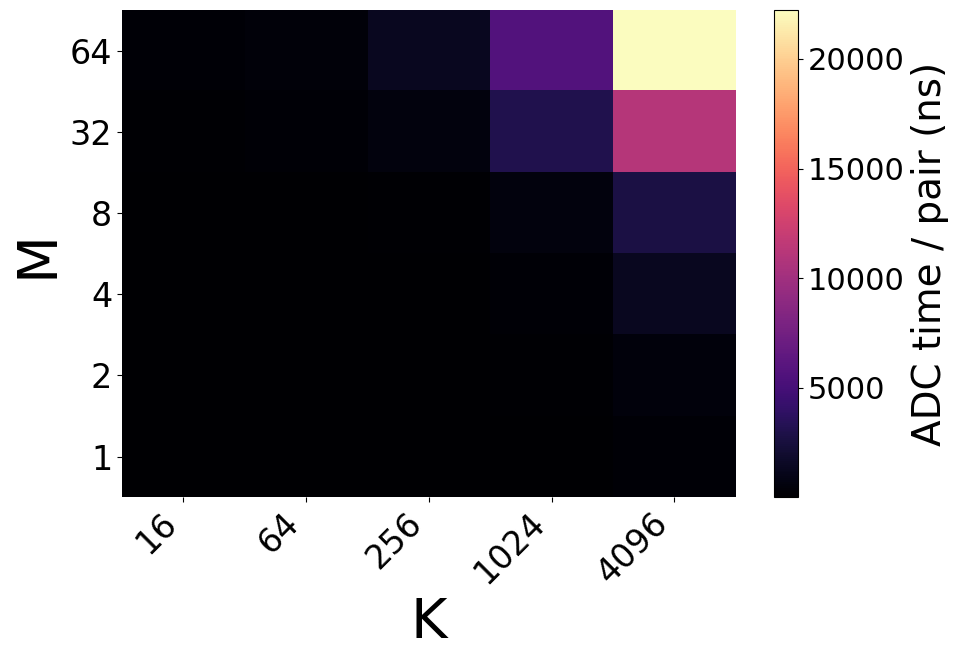

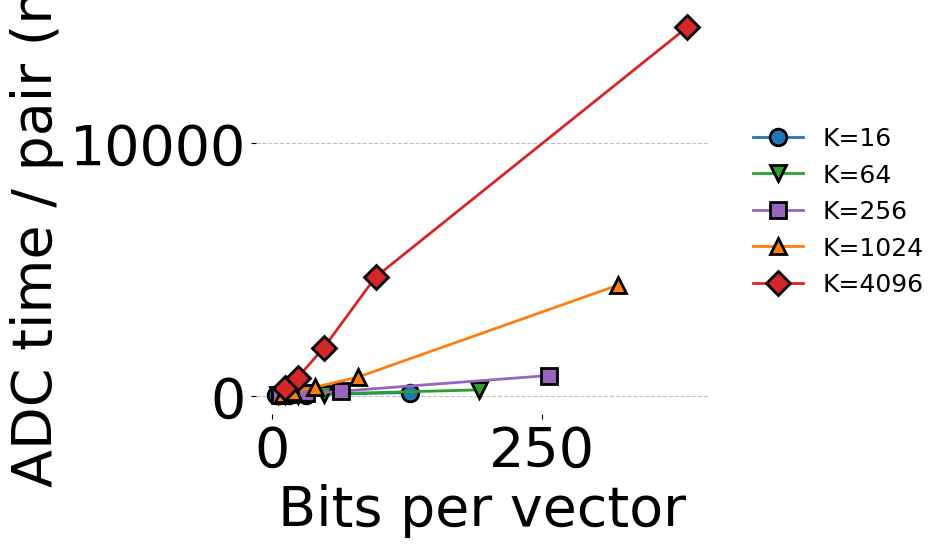

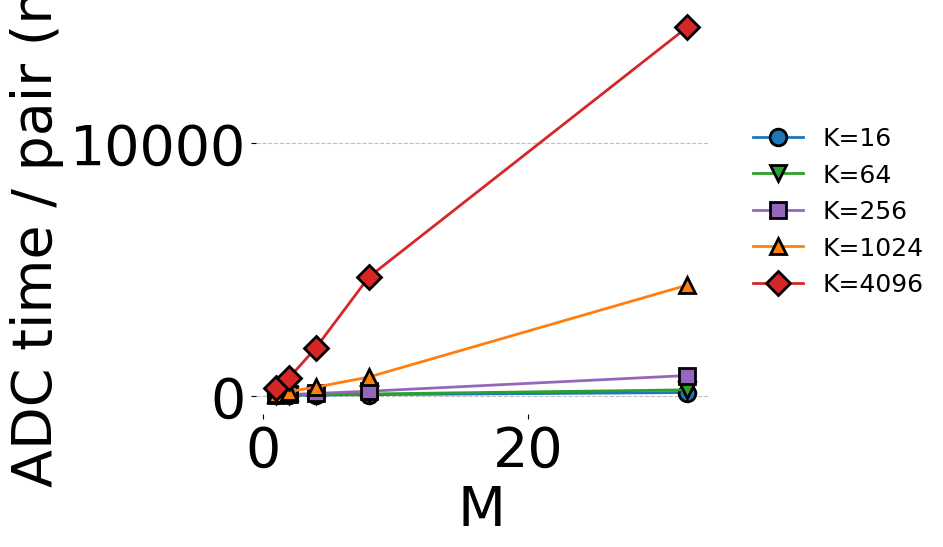

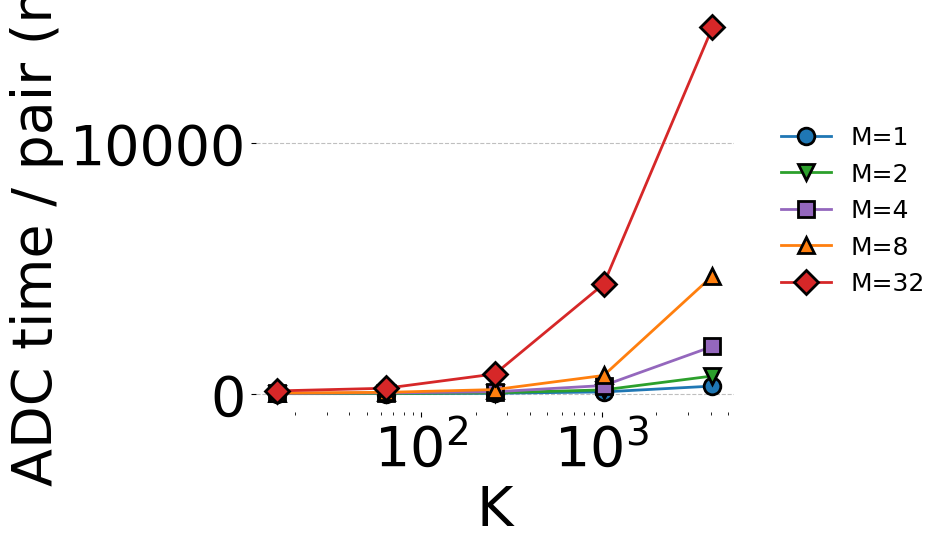

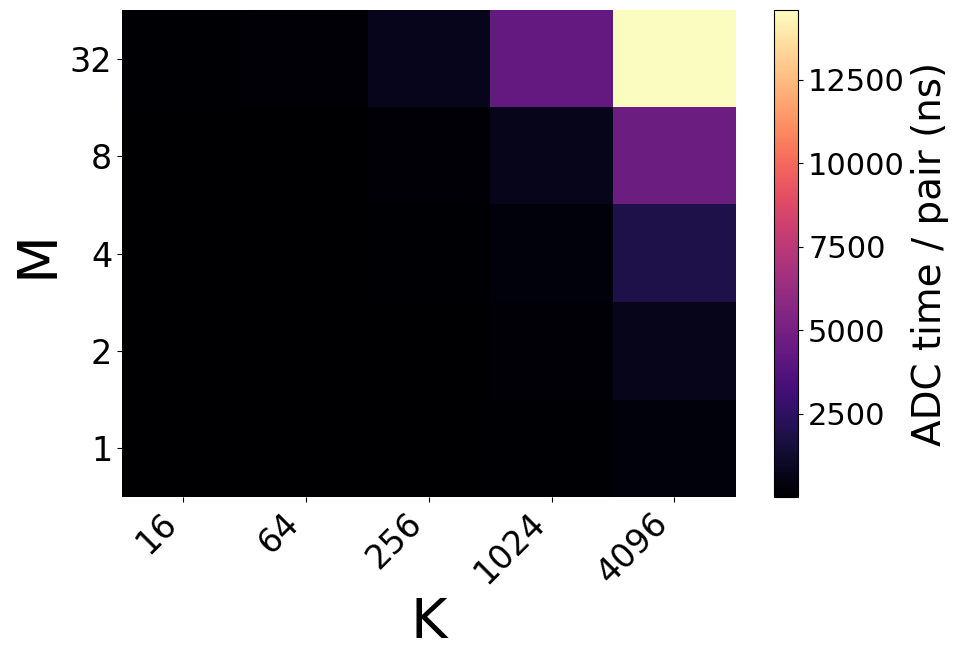

In [5]:
for dataset in DATASETS:
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='bits_per_vector',
        y_col='adc_time_per_pair_ns',
        group_col='K',
        x_label='Bits per vector',
        y_label='ADC time / pair (ns)',
        stem='adc_time_ns_vs_bits_per_vector_by_K',
        title=f'{dataset}: ADC time vs bits/vector',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='M',
        y_col='adc_time_per_pair_ns',
        group_col='K',
        x_label='M',
        y_label='ADC time / pair (ns)',
        stem='adc_time_ns_vs_M_by_K',
        title=f'{dataset}: ADC time vs M',
    )
    plot_lines_by_group(
        plot_df,
        dataset=dataset,
        x_col='K',
        y_col='adc_time_per_pair_ns',
        group_col='M',
        x_label='K',
        y_label='ADC time / pair (ns)',
        stem='adc_time_ns_vs_K_by_M',
        title=f'{dataset}: ADC time vs K',
        x_log=True,
    )
    plot_heatmap(
        plot_df,
        dataset=dataset,
        value_col='adc_time_per_pair_ns',
        value_label='ADC time / pair (ns)',
        stem='adc_time_ns_heatmap_M_by_K',
        cmap='magma',
    )


## Pareto: Relative Error vs ADC Time

Each point is one `(M, K)` configuration. Labels are `(M, K)` on the lower-left Pareto frontier.

Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/bigann_pareto_relerr_vs_adc_time.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/deep_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/deep_pareto_relerr_vs_adc_time.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/gist_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/gist_pareto_relerr_vs_adc_time.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/msmarco_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/msmarco_pareto_relerr_vs_adc_time.pdf
Saved: /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/openai_pareto_relerr_vs_adc_time.png, /mnthdd/cpanourg/2-hdvc/results/qinco/figures/qinco_res_relerr/ope

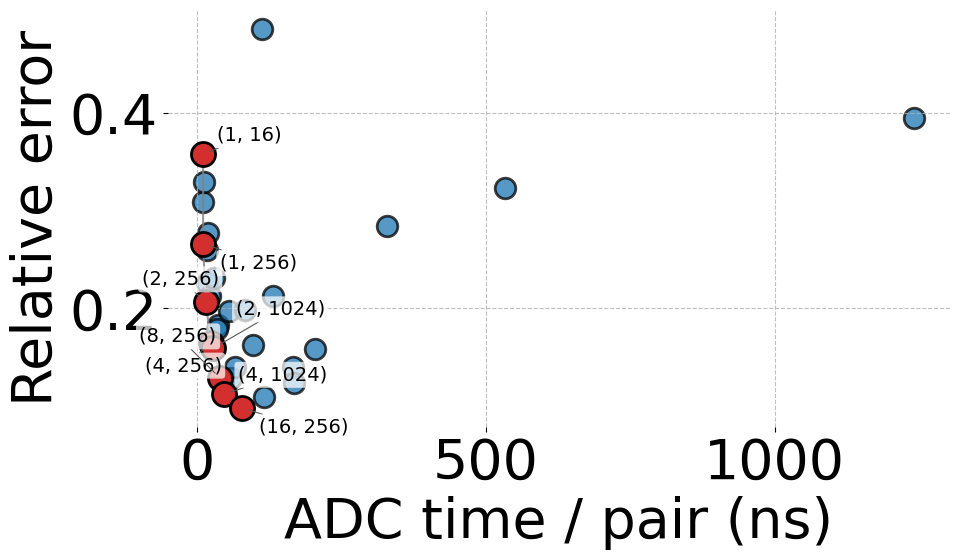

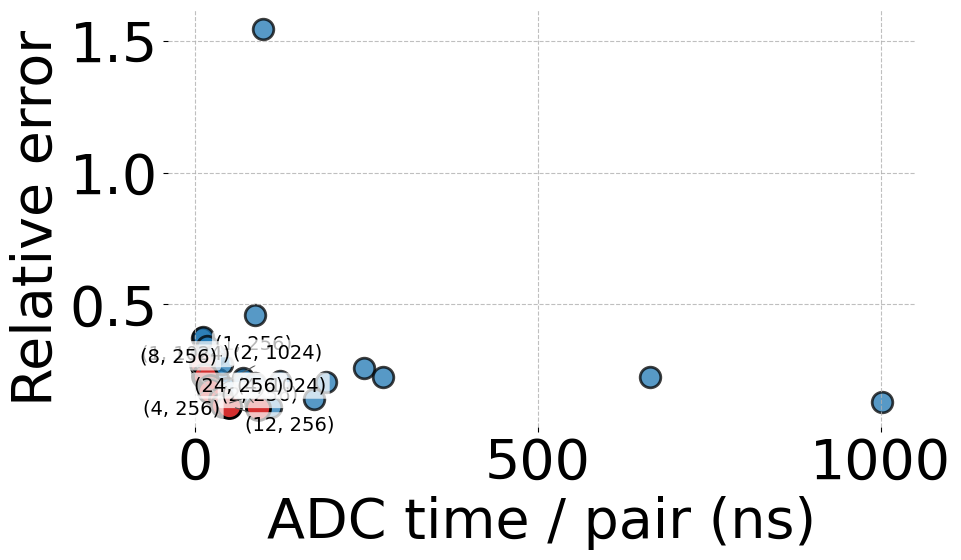

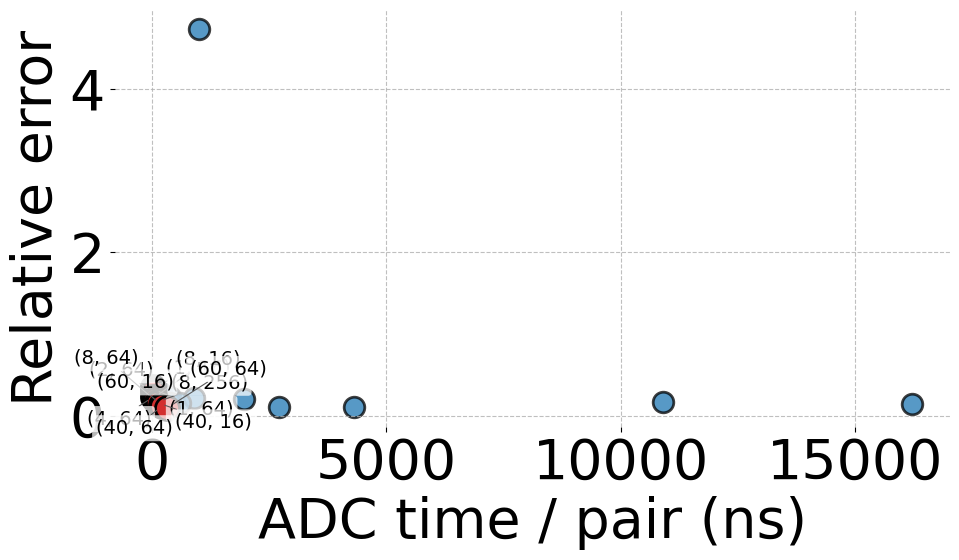

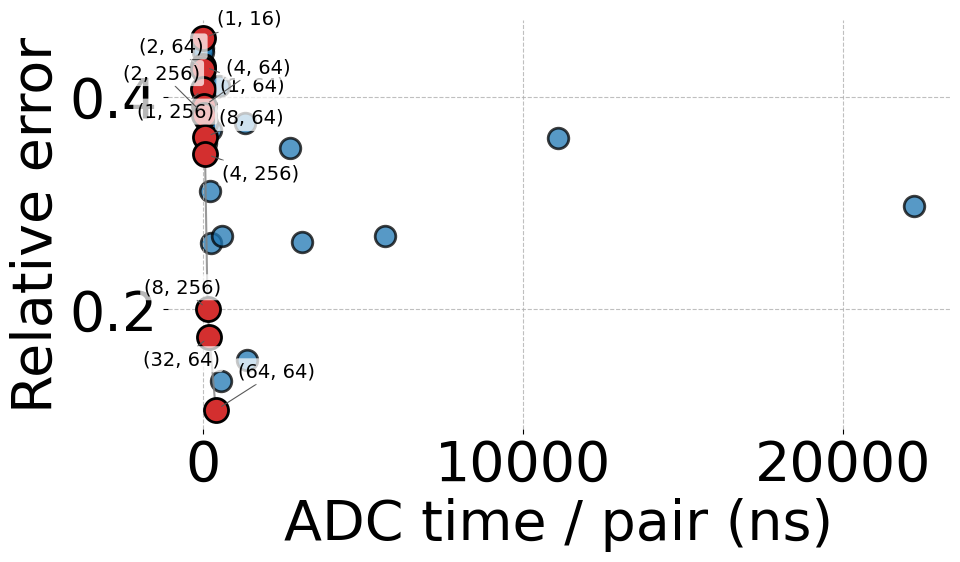

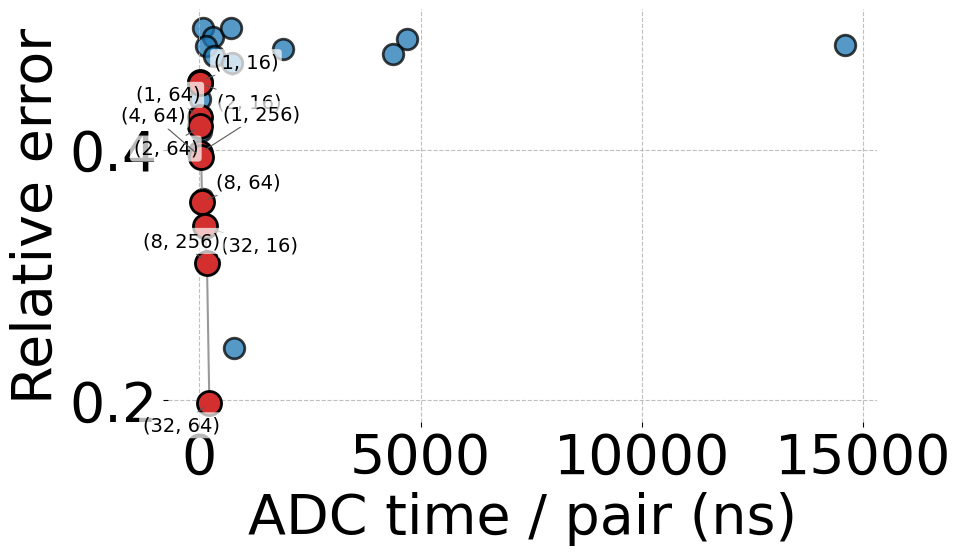

In [6]:
def pareto_frontier_minimize(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    pts = df.dropna(subset=[x_col, y_col]).sort_values([x_col, y_col]).copy()
    frontier = []
    best_y = np.inf
    for _, row in pts.iterrows():
        if row[y_col] < best_y:
            frontier.append(row)
            best_y = row[y_col]
    return pd.DataFrame(frontier) if frontier else pts.iloc[0:0]


def plot_pareto(dataset: str):
    sub = plot_df[plot_df['dataset'] == dataset].dropna(subset=['adc_time_per_pair_ns', 'rel_error_mean']).copy()
    if sub.empty:
        return None
    frontier = pareto_frontier_minimize(sub, 'adc_time_per_pair_ns', 'rel_error_mean')
    apply_relerr_cpp_rcparams()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(
        sub['adc_time_per_pair_ns'],
        sub['rel_error_mean'],
        color='tab:blue',
        marker='o',
        s=220,
        edgecolors='black',
        linewidths=2,
        alpha=0.75,
    )
    if not frontier.empty:
        ax.plot(frontier['adc_time_per_pair_ns'], frontier['rel_error_mean'], '-', color='gray', linewidth=1.5, alpha=0.8)
        ax.scatter(
            frontier['adc_time_per_pair_ns'],
            frontier['rel_error_mean'],
            color='#D32F2F',
            marker='o',
            s=300,
            edgecolors='black',
            linewidths=2,
            zorder=3,
        )
        offsets = [(10, 10), (12, -18), (-46, 12), (-48, -20), (16, 24), (-58, 26)]
        for i, (_, row) in enumerate(frontier.iterrows()):
            ax.annotate(
                f"({int(row['M'])}, {int(row['K'])})",
                (row['adc_time_per_pair_ns'], row['rel_error_mean']),
                xytext=offsets[i % len(offsets)],
                textcoords='offset points',
                fontsize=14,
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.72),
                arrowprops=dict(arrowstyle='-', color='0.35', lw=0.8, shrinkA=0, shrinkB=5),
            )
    style_axes(ax, 'ADC time / pair (ns)', 'Relative error', grid_axis='both')
    plt.tight_layout()
    save_figure(fig, f'{dataset}_pareto_relerr_vs_adc_time')
    return fig, ax

for dataset in DATASETS:
    plot_pareto(dataset)


## Combined Data Table

`plot_df` is the merged, aggregated table used for the plots.

In [7]:
display_cols = [
    'dataset', 'M', 'K', 'nbits', 'bits_per_vector',
    'adc_time_per_pair_ns', 'adc_time_s',
    'rel_error_mean', 'rel_error_std',
    'timing_rows', 'accuracy_rows',
]
plot_df[display_cols].sort_values(['dataset', 'bits_per_vector', 'M', 'K']).head(30)


,dataset,M,K,nbits,bits_per_vector,adc_time_per_pair_ns,adc_time_s,rel_error_mean,rel_error_std,timing_rows,accuracy_rows
0,bigann,1,16,4,4,10.109179,0.101092,0.357553,0.124413,1,1
1,bigann,1,64,6,6,10.338258,0.103383,0.308968,0.119529,1,1
2,bigann,1,256,8,8,10.166091,0.101661,0.266311,0.115638,1,1
3,bigann,2,16,4,8,12.498486,0.124985,0.328954,0.121042,1,1
4,bigann,1,1024,10,10,17.168177,0.171682,0.226253,0.110220,1,1
5,bigann,1,4096,12,12,35.103778,0.351038,0.182765,0.106876,1,1
6,bigann,2,64,6,12,16.440568,0.164406,0.259339,0.114080,1,1
7,bigann,2,256,8,16,14.299241,0.142992,0.207028,0.105033,1,1
8,bigann,4,16,4,16,18.247662,0.182477,0.277208,0.116237,1,1
9,bigann,2,1024,10,20,27.895586,0.278956,0.159265,0.096265,1,1
